<img src="https://s8.hostingkartinok.com/uploads/images/2018/08/308b49fcfbc619d629fe4604bceb67ac.jpg" width=500, height=450>
<h3 style="text-align: center;"><b>Физтех-Школа Прикладной математики и информатики (ФПМИ) МФТИ</b></h3>

---

***Some parts of the notebook are almost the copy of [ mmta-team course](https://github.com/mmta-team/mmta_fall_2020). Special thanks to mmta-team for making them publicly available. [Original notebook](https://github.com/mmta-team/mmta_fall_2020/blob/master/tasks/01_word_embeddings/task_word_embeddings.ipynb).***

<b> Прочитайте семинар, пожалуйста, для успешного выполнения домашнего задания. В конце ноутка напишите свой вывод. Работа без вывода оценивается ниже.

## Задача поиска схожих по смыслу предложений

Мы будем ранжировать вопросы [StackOverflow](https://stackoverflow.com) на основе семантического векторного представления

До этого в курсе не было речи про задачу ранжировния, поэтому введем математическую формулировку

## Задача ранжирования(Learning to Rank)

* $X$ - множество объектов
* $X^l = \{x_1, x_2, ..., x_l\}$ - обучающая выборка
<br>На обучающей выборке задан порядок между некоторыми элементами, то есть нам известно, что некий объект выборки более релевантный для нас, чем другой:
* $i \prec j$ - порядок пары индексов объектов на выборке $X^l$ c индексами $i$ и $j$
### Задача:
построить ранжирующую функцию $a$ : $X \rightarrow R$ такую, что
$$i \prec j \Rightarrow a(x_i) < a(x_j)$$

<img src="https://d25skit2l41vkl.cloudfront.net/wp-content/uploads/2016/12/Featured-Image.jpg" width=500, height=450>

### Embeddings

Будем использовать предобученные векторные представления слов на постах Stack Overflow.<br>
[A word2vec model trained on Stack Overflow posts](https://github.com/vefstathiou/SO_word2vec)

In [20]:
!wget https://zenodo.org/record/1199620/files/SO_vectors_200.bin?download=1

--2025-10-05 16:50:15--  https://zenodo.org/record/1199620/files/SO_vectors_200.bin?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.194, 188.185.43.25, 188.185.45.92, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.194|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/1199620/files/SO_vectors_200.bin [following]
--2025-10-05 16:50:16--  https://zenodo.org/records/1199620/files/SO_vectors_200.bin
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 1453905423 (1.4G) [application/octet-stream]
Saving to: ‘SO_vectors_200.bin?download=1’

SO_vectors_200.bin? 100%[===================>]   1.35G  21.4MB/s    in 6m 5s   

2025-10-05 16:56:21 (3.80 MB/s) - ‘SO_vectors_200.bin?download=1’ saved [1453905423/1453905423]



In [1]:
!pip install gensim==3.8.0 -q

In [2]:
  !pip install --upgrade gensim

  Using cached gensim-4.3.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
Using cached gensim-4.3.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26.6 MB)
  Attempting uninstall: gensim
    Found existing installation: gensim 3.8.0
    Uninstalling gensim-3.8.0:
      Successfully uninstalled gensim-3.8.0


In [3]:
from gensim.models.keyedvectors import KeyedVectors
wv_embeddings = KeyedVectors.load_word2vec_format("SO_vectors_200.bin?download=1", binary=True)

#### Как пользоваться этими векторами?

Посмотрим на примере одного слова, что из себя представляет embedding

In [4]:
word = 'dog'
if word in wv_embeddings:
    print(wv_embeddings[word].dtype, wv_embeddings[word].shape)

float32 (200,)


In [5]:
print(f"Num of words: {len(wv_embeddings.index_to_key)}")

Num of words: 1787145


Найдем наиболее близкие слова к слову `dog`:

#### ***Вопрос 1:***
* Входит ли слово `cat` в топ-5 близких слов к слову `dog`? Какое место оно занимает?


In [6]:
# method most_simmilar
'''your code'''
wv_embeddings.most_similar('dog')

[('animal', 0.8564180135726929),
 ('dogs', 0.7880866527557373),
 ('mammal', 0.7623804211616516),
 ('cats', 0.7621253728866577),
 ('animals', 0.760793924331665),
 ('feline', 0.7392398715019226),
 ('bird', 0.7315488457679749),
 ('animal1', 0.7219215631484985),
 ('doggy', 0.7213349342346191),
 ('labrador', 0.7209131717681885)]

In [7]:
word_find = 'cat'

for ind, word in enumerate(wv_embeddings.most_similar('dog')):
  if wv_embeddings.most_similar('dog')[ind][0] == word_find and ind <=5:
    ind+=1
    print(f'Слово {word_find} входит в топ-5 близких слов к слову dog и находится на месте {ind}')
    break
else:
  print(f'Слово {word_find} не входит в топ-5 близких слов к слову dog')

Слово cat не входит в топ-5 близких слов к слову dog


***Ваш ответ:*** 'cat' не входит в топ-5 ближайших слов к 'dog'.

Да, именно так, слово cat не входит в ближайшие пять, но входит слово cats(но по-идее это другое слово).

### Векторные представления текста

Перейдем от векторных представлений отдельных слов к векторным представлениям вопросов, как к **среднему** векторов всех слов в вопросе. Если для какого-то слова нет предобученного вектора, то его нужно пропустить. Если вопрос не содержит ни одного известного слова, то нужно вернуть нулевой вектор.

In [8]:
import numpy as np
import re
# you can use your tokenizer
# for example, from nltk.tokenize import WordPunctTokenizer
class MyTokenizer:
    def __init__(self):
        pass
    def tokenize(self, text):
        # return re.findall('\w+', text)
        return re.findall(r'\w+', text) # Добавлена 'r' перед строкой
tokenizer = MyTokenizer()

In [9]:
def question_to_vec(question, embeddings, tokenizer, dim=200):
    """
        question: строка
        embeddings: наше векторное представление
        dim: размер любого вектора в нашем представлении

        return: векторное представление для вопроса
    """

    '''your code'''
    embed_list = []
    for word in tokenizer.tokenize(question.lower()):
        try:
            embed_list.append(embeddings[word])
        except (KeyError):
            continue
    return np.mean(embed_list, axis=0) if len(embed_list) > 0 else np.zeros(dim, dtype='float32')

Теперь у нас есть метод для создания векторного представления любого предложения.

#### ***Вопрос 2:***

* Какая третья (с индексом 2) компонента вектора предложения `I love neural networks` (округлите до 2 знаков после запятой)?

In [10]:
# Предложение
question = "I love neural networks"

i = 2
print(f"Ответ: {question_to_vec(question, wv_embeddings, tokenizer)[i]:.2f}")

Ответ: -1.29


### Оценка близости текстов

Представим, что мы используем идеальные векторные представления слов. Тогда косинусное расстояние между дублирующими предложениями должно быть меньше, чем между случайно взятыми предложениями.

Сгенерируем для каждого из $N$ вопросов $R$ случайных отрицательных примеров и примешаем к ним также настоящие дубликаты. Для каждого вопроса будем ранжировать с помощью нашей модели $R + 1$ примеров и смотреть на позицию дубликата. Мы хотим, чтобы дубликат был первым в ранжированном списке.

#### Hits@K
Первой простой метрикой будет количество корректных попаданий для какого-то $K$:
$$ \text{Hits@K} = \frac{1}{N}\sum_{i=1}^N \, [rank\_q_i^{'} \le K],$$
* $\begin{equation*}
[x < 0 ] \equiv
 \begin{cases}
   1, &x < 0\\
   0, &x \geq 0
 \end{cases}
\end{equation*}$ - индикаторная функция
* $q_i$ - $i$-ый вопрос
* $q_i^{'}$ - его дубликат
* $rank\_q_i^{'}$ - позиция дубликата в ранжированном списке ближайших предложений для вопроса $q_i$.

Hits@K  измеряет долю вопросов, для которых правильный ответ попал в топ-K позиций среди отранжированных кандидатов.

#### DCG@K
Второй метрикой будет упрощенная DCG метрика, учитывающая порядок элементов в списке путем домножения релевантности элемента на вес равный обратному логарифму номера позиции::
$$ \text{DCG@K} = \frac{1}{N} \sum_{i=1}^N\frac{1}{\log_2(1+rank\_q_i^{'})}\cdot[rank\_q_i^{'} \le K],$$
С такой метрикой модель штрафуется за большой ранк корректного ответа.

DCG@K  измеряет качество ранжирования, учитывая не только факт наличия правильного ответа в топ-K, но и ***его точную позицию***.

<img src='https://hsto.org/files/1c5/edf/dee/1c5edfdeebce4b71a86bdf986d9f88f2.jpg' width=400, height=200>

#### Пример оценок

Вычислим описанные выше метрики для игрушечного примера.
Пусть
* $N = 1$, $R = 3$
* <font color='green'>"Что такое python?"</font> - вопрос $q_1$
* <font color='red'>"Что такое язык python?"</font> - его дубликат $q_i^{'}$

Пусть модель выдала следующий ранжированный список кандидатов:

1. "Как изучить с++?"
2. <font color='red'>"Что такое язык python?"</font>
3. "Хочу учить Java"
4. "Не понимаю Tensorflow"

$\Rightarrow rank\_q_i^{'} = 2$

Вычислим метрику *Hits@K* для *K = 1, 4*:

- [K = 1] $\text{Hits@1} =  [rank\_q_i^{'} \le 1]$

Проверяем условие $ \text{rank}_{q'_1} \leq 1 $: ***условие неверно***.

Следовательно, $[\text{rank}_{q'_1} \leq 1] = 0$.

- [K = 4] $\text{Hits@4} =  [rank\_q_i^{'} \le 4] = 1$

Проверяем условие $ \text{rank}_{q'_1} \leq 4 $: ***условие верно***.

Вычислим метрику *DCG@K* для *K = 1, 4*:
- [K = 1] $\text{DCG@1} = \frac{1}{\log_2(1+2)}\cdot[2 \le 1] = 0$
- [K = 4] $\text{DCG@4} = \frac{1}{\log_2(1+2)}\cdot[2 \le 4] = \frac{1}{\log_2{3}}$

#### ***Вопрос 3***:
* Вычислите `DCG@10`, если $rank\_q_i^{'} = 9$(округлите до одного знака после запятой)



In [11]:
print(f"Ответ: {round(1/(np.log2(1+9)),2)}")

Ответ: 0.3


#### Более сложный пример оценок

Рассмотрим пример с $ N > 1 $, где $ N = 3 $ (три вопроса) и для каждого вопроса заданы позиции их дубликатов. Вычислим метрики **Hits@K** для разных значений $ K $.

---

- $ N = 3 $: Три вопроса ($ q_1, q_2, q_3 $).
- Для каждого вопроса известна позиция его дубликата ($ \text{rank}_{q'_i} $):
  - $ \text{rank}_{q'_1} = 2 $,
  - $ \text{rank}_{q'_2} = 5 $,
  - $ \text{rank}_{q'_3} = 1 $.

Мы будем вычислять **Hits@K** для $ K = 1, 5 $.

---

**Для $ K = 1 $:**

Подставим значения:
$$
\text{Hits@1} = \frac{1}{3} \cdot \left( [\text{rank}_{q'_1} \leq 1] + [\text{rank}_{q'_2} \leq 1] + [\text{rank}_{q'_3} \leq 1] \right).
$$

Проверяем условие $ \text{rank}_{q'_i} \leq 1 $ для каждого вопроса:
- $ \text{rank}_{q'_1} = 2 $ → $ 2 \not\leq 1 $ → $ 0 $,
- $ \text{rank}_{q'_2} = 5 $ → $ 5 \not\leq 1 $ → $ 0 $,
- $ \text{rank}_{q'_3} = 1 $ → $ 1 \leq 1 $ → $ 1 $.

Сумма:
$$
\text{Hits@1} = \frac{1}{3} \cdot (0 + 0 + 1) = \frac{1}{3}.
$$

$$
\boxed{\text{Hits@1} = \frac{1}{3}}.
$$

---

**Для $ K = 5 $:**

Подставим значения:
$$
\text{Hits@5} = \frac{1}{3} \cdot \left( [\text{rank}_{q'_1} \leq 5] + [\text{rank}_{q'_2} \leq 5] + [\text{rank}_{q'_3} \leq 5] \right).
$$

Проверяем условие $ \text{rank}_{q'_i} \leq 5 $ для каждого вопроса:
- $ \text{rank}_{q'_1} = 2 $ → $ 2 \leq 5 $ → $ 1 $,
- $ \text{rank}_{q'_2} = 5 $ → $ 5 \leq 5 $ → $ 1 $,
- $ \text{rank}_{q'_3} = 1 $ → $ 1 \leq 5 $ → $ 1 $.

Сумма:
$$
\text{Hits@5} = \frac{1}{3} \cdot (1 + 1 + 1) = 1.
$$

$$
\boxed{\text{Hits@5} = 1}.
$$

Теперь вычислим метрику **DCG@K** для того же примера, где $ N = 3 $ (три вопроса), и для каждого вопроса известна позиция его дубликата ($ \text{rank}_{q'_i} $):

- $ \text{rank}_{q'_1} = 2 $,
- $ \text{rank}_{q'_2} = 5 $,
- $ \text{rank}_{q'_3} = 1 $.

Мы будем вычислять **DCG@K** для $ K = 1, 5 $.

---
**Для $ K = 1 $:**
Подставим значения:
$$
\text{DCG@1} = \frac{1}{3} \cdot \left( \frac{1}{\log_2(1 + \text{rank}_{q'_1})} \cdot [\text{rank}_{q'_1} \leq 1] + \frac{1}{\log_2(1 + \text{rank}_{q'_2})} \cdot [\text{rank}_{q'_2} \leq 1] + \frac{1}{\log_2(1 + \text{rank}_{q'_3})} \cdot [\text{rank}_{q'_3} \leq 1] \right).
$$

Проверяем условие $ \text{rank}_{q'_i} \leq 1 $ для каждого вопроса:
- $ \text{rank}_{q'_1} = 2 $ → $ 2 \not\leq 1 $ → $ 0 $,
- $ \text{rank}_{q'_2} = 5 $ → $ 5 \not\leq 1 $ → $ 0 $,
- $ \text{rank}_{q'_3} = 1 $ → $ 1 \leq 1 $ → $ 1 $.

Сумма:
$$
\text{DCG@1} = \frac{1}{3} \cdot (0 + 0 + 1) = \frac{1}{3}.
$$
$$
\boxed{\text{DCG@1} = \frac{1}{3}}.
$$

---


**Для $ K = 5 $:**
Подставим значения:
$$
\text{DCG@5} = \frac{1}{3} \cdot \left( \frac{1}{\log_2(1 + \text{rank}_{q'_1})} \cdot [\text{rank}_{q'_1} \leq 5] + \frac{1}{\log_2(1 + \text{rank}_{q'_2})} \cdot [\text{rank}_{q'_2} \leq 5] + \frac{1}{\log_2(1 + \text{rank}_{q'_3})} \cdot [\text{rank}_{q'_3} \leq 5] \right).
$$

Проверяем условие $ \text{rank}_{q'_i} \leq 5 $ для каждого вопроса:
- $ \text{rank}_{q'_1} = 2 $ → $ 2 \leq 5 $ → $ 1 $,
- $ \text{rank}_{q'_2} = 5 $ → $ 5 \leq 5 $ → $ 1 $,
- $ \text{rank}_{q'_3} = 1 $ → $ 1 \leq 5 $ → $ 1 $.

Сумма:
$$
\text{DCG@5} = \frac{1}{3} \cdot (0.631 + 0.387 + 1) = \frac{1}{3} \cdot 2.018 \approx 0.673.
$$

$$
\boxed{\text{DCG@5} \approx 0.673}.
$$

#### ***Вопрос 4:***
* Найдите максимум `Hits@47 - DCG@1`?



In [11]:
# Ответ: 1, когда ранги всех возможных дубликатов лежат в (1; 47].

### HITS\_COUNT и DCG\_SCORE

Каждая функция имеет два аргумента: $dup\_ranks$ и $k$.

$dup\_ranks$ является списком, который содержит рейтинги дубликатов (их позиции в ранжированном списке).

К примеру для <font color='red'>"Что такое язык python?"</font> $dup\_ranks = [2]$.

In [12]:
def hits_count(dup_ranks, k):
    """
        dup_ranks: list индексов дубликатов
        k: пороговое значение для ранга
        result: вернуть Hits@k
    """
    # Подсчитываем количество дубликатов, чей ранг <= k
    p = 0
    for i in dup_ranks:
      if i <= k:
        p += 1
    hits_value = p / len(dup_ranks)
    return hits_value

In [13]:
dup_ranks = [2]

k = 1
hits_value = hits_count(dup_ranks, k)
print(f"Hits@1 = {hits_value}")

k = 4
hits_value = hits_count(dup_ranks, k)
print(f"Hits@4 = {hits_value}")

Hits@1 = 0.0
Hits@4 = 1.0


In [14]:
import math

def dcg_score(dup_ranks, k):
    """
        dup_ranks: list индексов дубликатов
        k: пороговое значение для ранга
        result: вернуть DCG@k
    """
    # Вычисляем сумму для всех релевантных дубликатов
    dcg_sum = 0
    for i in dup_ranks:
      if i <= k:
        dcg_sum += 1/np.log2(1+i)

    # Делим на общее количество вопросов
    dcg_value = dcg_sum / len(dup_ranks)

    return dcg_value

In [15]:
# Пример списка позиций дубликатов
dup_ranks = [2]

# Вычисляем DCG@1
dcg_value = dcg_score(dup_ranks, k=1)
print(f"DCG@1 = {dcg_value:.3f}")

# Вычисляем DCG@4
dcg_value = dcg_score(dup_ranks, k=4)
print(f"DCG@10 = {dcg_value:.3f}")

DCG@1 = 0.000
DCG@10 = 0.631


Протестируем функции. Пусть $N = 1$, то есть один эксперимент. Будем искать копию вопроса и оценивать метрики.

In [16]:
import pandas as pd

In [17]:
copy_answers = ["How does the catch keyword determine the type of exception that was thrown",]

# наши кандидаты
candidates_ranking = [["How Can I Make These Links Rotate in PHP",
                       "How does the catch keyword determine the type of exception that was thrown",
                       "NSLog array description not memory address",
                       "PECL_HTTP not recognised php ubuntu"],]

# dup_ranks — позиции наших копий, так как эксперимент один, то этот массив длины 1
# dup_ranks = ['''your code''']
dict_ranking = {candidate: rank+1 for rank, candidate in enumerate(candidates_ranking[0])}
dup_ranks = [dict_ranking[copy_answers[0]]]


# вычисляем метрику для разных k
print('Ваш ответ HIT:', [hits_count(dup_ranks, k) for k in range(1, 5)])
print('Ваш ответ DCG:', [round(dcg_score(dup_ranks, k), 5) for k in range(1, 5)])

Ваш ответ HIT: [0.0, 1.0, 1.0, 1.0]
Ваш ответ DCG: [0.0, 0.63093, 0.63093, 0.63093]


У вас должно получиться

In [18]:
# correct_answers - метрика для разных k
correct_answers = pd.DataFrame([[0, 1, 1, 1], [0, 1 / (np.log2(3)), 1 / (np.log2(3)), 1 / (np.log2(3))]],
                               index=['HITS', 'DCG'], columns=range(1,5))
correct_answers

,1,2,3,4
HITS,0,1.00000,1.00000,1.00000
DCG,0,0.63093,0.63093,0.63093


### Данные
[arxiv link](https://drive.google.com/file/d/1QqT4D0EoqJTy7v9VrNCYD-m964XZFR7_/edit)

`train.tsv` - выборка для обучения.<br> В каждой строке через табуляцию записаны: **<вопрос>, <похожий вопрос>**

`validation.tsv` - тестовая выборка.<br> В каждой строке через табуляцию записаны: **<вопрос>, <похожий вопрос>, <отрицательный пример 1>, <отрицательный пример 2>, ...**

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# !unzip stackoverflow_similar_questions.zip
!unzip /content/drive/MyDrive/stackoverflow_similar_questions.zip

Archive:  /content/drive/MyDrive/stackoverflow_similar_questions.zip
replace data/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

Считайте данные.

In [21]:
def read_corpus(filename):
    data = []
    with open(filename, encoding='utf-8') as file:
        for line in file:
            data.append(line.strip().split('\t'))
    return data

Нам понадобиться только файл validation.

In [22]:
validation_data = read_corpus('./data/validation.tsv')

Кол-во строк

In [23]:
len(validation_data)

3760

Размер нескольких первых строк

In [24]:
for i in range(25):
    print(i + 1, len(validation_data[i]))

1 1001
2 1001
3 1001
4 1001
5 1001
6 1001
7 1001
8 1001
9 1001
10 1001
11 1001
12 1001
13 1001
14 1001
15 1001
16 1001
17 1001
18 1001
19 1001
20 1001
21 1001
22 1001
23 1001
24 1001
25 1001


### Ранжирование без обучения

Реализуйте функцию ранжирования кандидатов на основе косинусного расстояния. Функция должна по списку кандидатов вернуть отсортированный список пар (позиция в исходном списке кандидатов, кандидат). При этом позиция кандидата в полученном списке является его рейтингом (первый - лучший). Например, если исходный список кандидатов был [a, b, c], и самый похожий на исходный вопрос среди них - c, затем a, и в конце b, то функция должна вернуть список **[(2, c), (0, a), (1, b)]**.

In [25]:
from sklearn.metrics.pairwise import cosine_similarity
from copy import deepcopy

In [26]:
def rank_candidates(question, candidates, embeddings, tokenizer, dim=200):
    """
        question: строка
        candidates: массив строк(кандидатов) [a, b, c]
        result: пары (начальная позиция, кандидат) [(2, c), (0, a), (1, b)]
    """
    question_emb = question_to_vec(question, embeddings, tokenizer, dim).reshape(1,-1)
    candidates_emb = [question_to_vec(c, embeddings, tokenizer, dim) for c in candidates]
    cosinus_s = pd.Series(cosine_similarity(question_emb,candidates_emb).squeeze()).sort_values()
    result = [(i, candidates[i]) for i in cosinus_s.index][::-1]
    return result

Протестируйте работу функции на примерах ниже. Пусть $N=2$, то есть два эксперимента

In [27]:
questions = ['converting string to list', 'Sending array via Ajax fails']

candidates = [['Convert Google results object (pure js) to Python object', # первый эксперимент
               'C# create cookie from string and send it',
               'How to use jQuery AJAX for an outside domain?'],

              ['Getting all list items of an unordered list in PHP',      # второй эксперимент
               'WPF- How to update the changes in list item of a list',
               'select2 not displaying search results']]

In [28]:
for question, q_candidates in zip(questions, candidates):
        ranks = rank_candidates(question, q_candidates, wv_embeddings, tokenizer)
        print(ranks)
        print()

[(1, 'C# create cookie from string and send it'), (0, 'Convert Google results object (pure js) to Python object'), (2, 'How to use jQuery AJAX for an outside domain?')]

[(0, 'Getting all list items of an unordered list in PHP'), (2, 'select2 not displaying search results'), (1, 'WPF- How to update the changes in list item of a list')]



Для первого экперимента вы можете полностью сравнить ваши ответы и правильные ответы. Но для второго эксперимента два ответа на кандидаты будут <b>скрыты</b>(*)

In [29]:
results = list()
for question, q_candidates in zip(questions, candidates):
  ranks = rank_candidates(question, q_candidates, wv_embeddings, tokenizer)
  print(ranks)
  print()
  results.append(ranks)

[(1, 'C# create cookie from string and send it'), (0, 'Convert Google results object (pure js) to Python object'), (2, 'How to use jQuery AJAX for an outside domain?')]

[(0, 'Getting all list items of an unordered list in PHP'), (2, 'select2 not displaying search results'), (1, 'WPF- How to update the changes in list item of a list')]



In [30]:
results

[[(1, 'C# create cookie from string and send it'),
  (0, 'Convert Google results object (pure js) to Python object'),
  (2, 'How to use jQuery AJAX for an outside domain?')],
 [(0, 'Getting all list items of an unordered list in PHP'),
  (2, 'select2 not displaying search results'),
  (1, 'WPF- How to update the changes in list item of a list')]]

In [ ]:
# # должно вывести
# results = [[(1, 'C# create cookie from string and send it'),
#             (0, 'Convert Google results object (pure js) to Python object'),
#             (2, 'How to use jQuery AJAX for an outside domain?')],
#            [(*, 'Getting all list items of an unordered list in PHP'), #скрыт
#             (*, 'select2 not displaying search results'), #скрыт
#             (*, 'WPF- How to update the changes in list item of a list')]] #скрыт

Последовательность начальных индексов вы должны получить `для эксперимента 1`  1, 0, 2.

In [ ]:
# Так и есть, последовательность - 1, 0, 2

#### ***Вопрос 5:***
* Какую последовательность начальных индексов вы получили `для эксперимента 2`(перечисление без запятой и пробелов, например, `102` для первого эксперимента?


In [31]:
# для токенайзеров - MyTokenizer(), SpacyTokenizer(), WordPunctTokenizer()
rez_2 = ''
for rank in ranks:
    rez_2 += str(rank[0])
print('\033[1m',rez_2)

 021


In [ ]:
# ОТвет: 021

Теперь мы можем оценить качество нашего метода. Запустите следующие два блока кода для получения результата. Обратите внимание, что вычисление расстояния между векторами занимает некоторое время (примерно 10 минут). Можете взять для validation 1000 примеров.

In [32]:
from tqdm.notebook import tqdm

In [33]:
wv_ranking = []
max_validation_examples = 1000
for i, line in enumerate(tqdm(validation_data)):
    if i == max_validation_examples:
        break
    q, *ex = line
    ranks = rank_candidates(q, ex, wv_embeddings, tokenizer)
    wv_ranking.append([r[0] for r in ranks].index(0) + 1)

  0%|          | 0/3760 [00:00<?, ?it/s]

In [34]:
for k in tqdm([1, 5, 10, 100, 500, 1000]):
    print("DCG@%4d: %.3f | Hits@%4d: %.3f" % (k, dcg_score(wv_ranking, k), k, hits_count(wv_ranking, k)))

  0%|          | 0/6 [00:00<?, ?it/s]

DCG@   1: 0.415 | Hits@   1: 0.415
DCG@   5: 0.502 | Hits@   5: 0.582
DCG@  10: 0.524 | Hits@  10: 0.650
DCG@ 100: 0.570 | Hits@ 100: 0.874
DCG@ 500: 0.583 | Hits@ 500: 0.973
DCG@1000: 0.586 | Hits@1000: 1.000


Из формул выше можно понять, что

- $ \text{Hits@K} $ **монотонно неубывающая функция** $ K $, которая стремится к 1 при $ K \to \infty $.

- $ \text{DCG@K} $ **монотонно неубывающая функция** $ K $, но рост замедляется с увеличением $ K $ из-за убывания веса $ \frac{1}{\log_2(1 + \text{rank}_{q'_i})} $.

### Эмбеддинги, обученные на корпусе похожих вопросов

In [35]:
train_data = read_corpus('./data/train.tsv')

Улучшите качество модели.<br>Склеим вопросы в пары и обучим на них модель Word2Vec из gensim. Выберите размер window. Объясните свой выбор.

***Рассмотрим подробнее*** данное склеивание.

1. Каждая строка из train_data разбивается на вопрос (question) и список кандидатов.

2. Для каждого кандидата вопрос склеивается с ним в одну строку.

3. Склеенная строка (combined_text) токенизируется, и полученный список токенов добавляется в общий корпус (corpus).

***Пример***

    Вопрос: "What is Python?"
    Кандидаты: ["Python is a programming language", "Java is another language"]
    Склеенные строки:
        "What is Python? Python is a programming language"
        "What is Python? Java is another language"
         
    Токенизированные списки:
        ['what', 'is', 'python', 'python', 'is', 'a', 'programming', 'language']
        ['what', 'is', 'python', 'java', 'is', 'another', 'language']
         
     

In [36]:
train_data[111258]

['Determine if the device is a smartphone or tablet?',
 'Change imageView params in all cards together']

In [37]:
# Создаем общий корпус текстов
# corpus = []

corpus = [list(tokenizer.tokenize(" ".join(corp))) for corp in train_data]

In [38]:
corpus[0]

['converting',
 'string',
 'to',
 'list',
 'Convert',
 'Google',
 'results',
 'object',
 'pure',
 'js',
 'to',
 'Python',
 'object']

In [ ]:
# from gensim.models import Word2Vec
# embeddings_trained = Word2Vec(
#     sentences=corpus,        # Корпус токенизированных текстов
#     vector_size=200,         # Размерность векторов
#     window=3,                # Размер окна контекста
#     min_count=5,             # Минимальная частота слов
#     workers=4                # Количество потоков
# ).wv

In [ ]:
# wv_ranking = []
# max_validation_examples = 1000
# for i, line in enumerate(tqdm(validation_data)):
#     if i == max_validation_examples:
#         break
#     q, *ex = line
#     ranks = rank_candidates(q, ex, embeddings_trained, tokenizer)
#     wv_ranking.append([r[0] for r in ranks].index(0) + 1)

In [ ]:
# for k in tqdm([1, 5, 10, 100, 500, 1000]):
#     print("DCG@%4d: %.3f | Hits@%4d: %.3f" % (k, dcg_score(wv_ranking, k), k, hits_count(wv_ranking, k)))

In [42]:
# Варьируем гипрерпараметры window, vector_size, min_count выполнив соответствующие прогоны кода для каждой из комбинаций

from gensim.models import Word2Vec
from tqdm import tqdm
import pandas as pd

# гиперпараметры
window_sizes = [3, 5, 7, 10]
vector_sizes = [200, 300, 500]
min_counts = [2, 3, 5]

results = []

max_validation_examples = 1000
ks = [1, 5, 10, 100, 500, 1000]

for wnd in window_sizes:
    for vs in vector_sizes:
        for mc in min_counts:
            print(f"\n Обучение модели: window_size={wnd}, vector_size={vs}, min_count={mc}")

            embeddings_trained = Word2Vec(
                corpus,
                vector_size=vs,
                min_count=mc,
                window=wnd
            ).wv

            # список рангов
            wv_ranking = []
            for i, line in enumerate(tqdm(validation_data, total=max_validation_examples)):
                if i == max_validation_examples:
                    break
                q, *ex = line
                ranks = rank_candidates(q, ex, embeddings_trained, tokenizer, vs)
                wv_ranking.append([r[0] for r in ranks].index(0) + 1)

            # считаем метрики для всех k
            row = {
                "window_size": wnd,
                "vector_size": vs,
                "min_count": mc
            }

            for k in ks:
                row[f"DCG@{k}"] = dcg_score(wv_ranking, k)
                row[f"Hits@{k}"] = hits_count(wv_ranking, k)
                print(f"DCG@{k:4d}: {row[f'DCG@{k}']:.3f} | Hits@{k:4d}: {row[f'Hits@{k}']:.3f}")

            results.append(row)
            print("-" * 40)

# --- Сводная таблица ---
df_results = pd.DataFrame(results)

print("\n Сводная таблица результатов:")
print(df_results)

df_results.to_csv("word2vec_experiments_summary.csv", index=False)
print("\n💾 Результаты сохранены в 'word2vec_experiments_summary.csv'")



 Обучение модели: window_size=3, vector_size=200, min_count=2


100%|██████████| 1000/1000 [01:18<00:00, 12.72it/s]


DCG@   1: 0.250 | Hits@   1: 0.250
DCG@   5: 0.319 | Hits@   5: 0.384
DCG@  10: 0.340 | Hits@  10: 0.448
DCG@ 100: 0.390 | Hits@ 100: 0.699
DCG@ 500: 0.417 | Hits@ 500: 0.912
DCG@1000: 0.426 | Hits@1000: 1.000
----------------------------------------

 Обучение модели: window_size=3, vector_size=200, min_count=3


100%|██████████| 1000/1000 [01:16<00:00, 13.16it/s]


DCG@   1: 0.252 | Hits@   1: 0.252
DCG@   5: 0.321 | Hits@   5: 0.382
DCG@  10: 0.340 | Hits@  10: 0.443
DCG@ 100: 0.392 | Hits@ 100: 0.696
DCG@ 500: 0.419 | Hits@ 500: 0.908
DCG@1000: 0.429 | Hits@1000: 1.000
----------------------------------------

 Обучение модели: window_size=3, vector_size=200, min_count=5


...

DCG@   1: 0.279 | Hits@   1: 0.279
DCG@   5: 0.355 | Hits@   5: 0.420
DCG@  10: 0.378 | Hits@  10: 0.491
DCG@ 100: 0.427 | Hits@ 100: 0.736
DCG@ 500: 0.451 | Hits@ 500: 0.923
DCG@1000: 0.460 | Hits@1000: 1.000
----------------------------------------

 Обучение модели: window_size=10, vector_size=500, min_count=3


100%|██████████| 1000/1000 [01:20<00:00, 12.37it/s]


DCG@   1: 0.276 | Hits@   1: 0.276
DCG@   5: 0.354 | Hits@   5: 0.421
DCG@  10: 0.374 | Hits@  10: 0.483
DCG@ 100: 0.426 | Hits@ 100: 0.736
DCG@ 500: 0.450 | Hits@ 500: 0.923
DCG@1000: 0.458 | Hits@1000: 1.000
----------------------------------------

 Обучение модели: window_size=10, vector_size=500, min_count=5


100%|██████████| 1000/1000 [01:20<00:00, 12.40it/s]


DCG@   1: 0.277 | Hits@   1: 0.277
DCG@   5: 0.351 | Hits@   5: 0.417
DCG@  10: 0.371 | Hits@  10: 0.478
DCG@ 100: 0.425 | Hits@ 100: 0.742
DCG@ 500: 0.448 | Hits@ 500: 0.922
DCG@1000: 0.456 | Hits@1000: 1.000
----------------------------------------

 Сводная таблица результатов:
    window_size  vector_size  min_count  DCG@1  Hits@1     DCG@5  Hits@5  \
0             3          200          2  0.250   0.250  0.319061   0.384   
1             3          200          3  0.252   0.252  0.320534   0.382   
2             3          200          5  0.250   0.250  0.317635   0.379   
3             3          300          2  0.249   0.249  0.318061   0.380   
4             3          300          3  0.246   0.246  0.317032   0.382   
5             3          300          5  0.251   0.251  0.315520   0.374   
6             3          500          2  0.252   0.252  0.317988   0.379   
7             3          500          3  0.246   0.246  0.316553   0.382   
8             3          500      

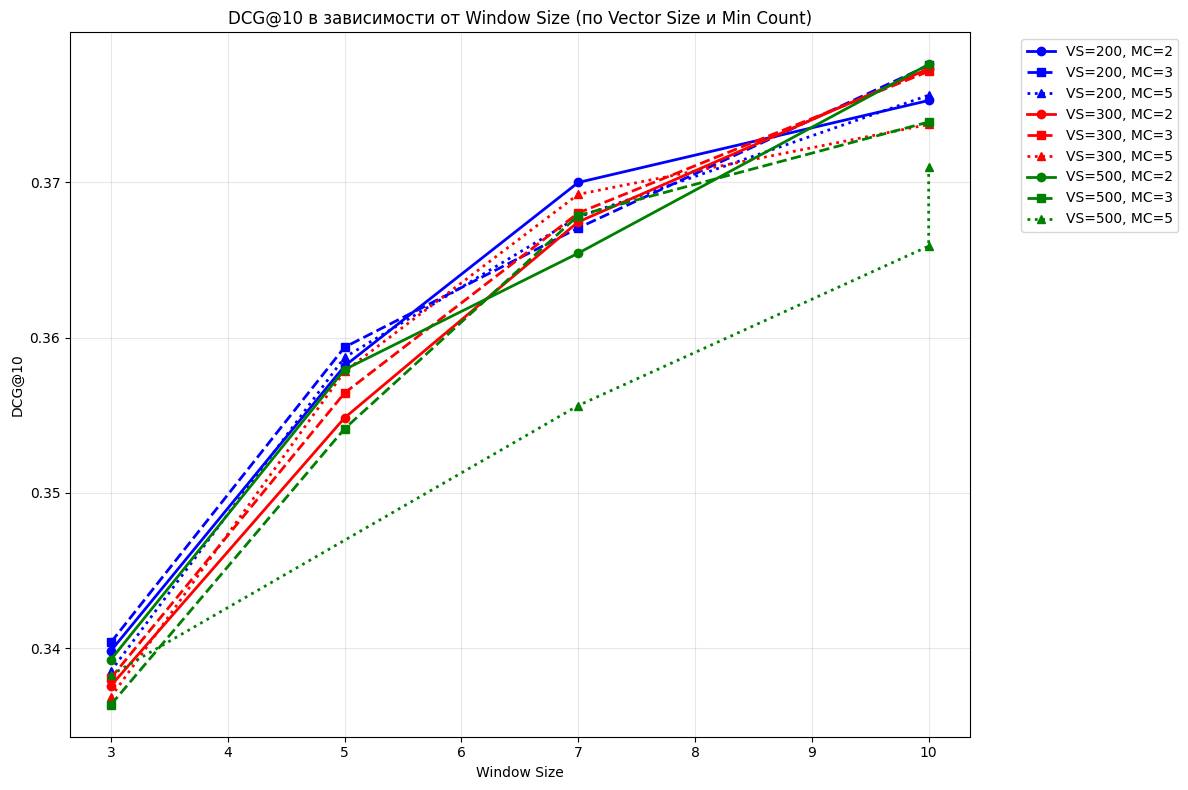

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'window_size': [3,3,3,3,3,3,3,3,3,5,5,5,5,5,5,5,5,7,7,7,7,7,7,7,7,7,10,10,10,10,10,10,10,10,10,10],
    'vector_size': [200,200,200,300,300,300,500,500,500,200,200,200,300,300,300,500,500,500,200,200,200,300,300,300,500,500,500,200,200,200,300,300,300,500,500,500],
    'min_count': [2,3,5,2,3,5,2,3,5,2,3,5,2,3,5,2,3,5,2,3,5,2,3,5,2,3,5,2,3,5,2,3,5,2,3,5],
    'DCG@1': [0.250, 0.252, 0.250, 0.249, 0.246, 0.251, 0.252, 0.246, 0.248, 0.262, 0.268, 0.269, 0.262, 0.263, 0.266, 0.264, 0.261, 0.267, 0.276, 0.276, 0.269, 0.273, 0.272, 0.277, 0.269, 0.277, 0.267, 0.281, 0.283, 0.282, 0.284, 0.282, 0.279, 0.279, 0.276, 0.277],
    'Hits@1': [0.250, 0.252, 0.250, 0.249, 0.246, 0.251, 0.252, 0.246, 0.248, 0.262, 0.268, 0.269, 0.262, 0.263, 0.266, 0.264, 0.261, 0.267, 0.276, 0.276, 0.269, 0.273, 0.272, 0.277, 0.269, 0.277, 0.267, 0.281, 0.283, 0.282, 0.284, 0.282, 0.279, 0.279, 0.276, 0.277],
    'DCG@5': [0.319061, 0.320534, 0.317635, 0.318061, 0.317032, 0.315520, 0.317988, 0.316553, 0.315943, 0.335623, 0.333617, 0.336111, 0.333715, 0.336093, 0.333542, 0.335647, 0.336216, 0.336152, 0.347892, 0.346773, 0.347266, 0.346263, 0.346935, 0.347425, 0.345220, 0.347183, 0.344175, 0.357147, 0.355443, 0.354822, 0.358521, 0.357217, 0.353955, 0.354874, 0.353764, 0.351415],
    'Hits@5': [0.384, 0.382, 0.379, 0.380, 0.382, 0.374, 0.379, 0.382, 0.378, 0.402, 0.391, 0.396, 0.400, 0.404, 0.394, 0.400, 0.406, 0.399, 0.411, 0.410, 0.416, 0.409, 0.413, 0.409, 0.412, 0.410, 0.411, 0.425, 0.419, 0.422, 0.426, 0.424, 0.421, 0.420, 0.421, 0.417],
    'DCG@10': [0.339838, 0.340385, 0.338536, 0.337587, 0.338084, 0.336866, 0.339274, 0.336365, 0.338279, 0.358178, 0.359387, 0.358734, 0.354839, 0.356440, 0.357826, 0.357947, 0.354138, 0.355631, 0.369997, 0.367067, 0.367768, 0.367458, 0.368033, 0.369233, 0.365442, 0.367869, 0.365898, 0.375279, 0.377541, 0.375616, 0.377325, 0.377156, 0.373735, 0.377605, 0.373893, 0.370997],
    'Hits@10': [0.448, 0.443, 0.443, 0.440, 0.447, 0.439, 0.444, 0.443, 0.447, 0.472, 0.469, 0.465, 0.465, 0.467, 0.469, 0.469, 0.461, 0.459, 0.479, 0.472, 0.480, 0.475, 0.479, 0.477, 0.475, 0.473, 0.478, 0.481, 0.487, 0.486, 0.485, 0.486, 0.482, 0.491, 0.483, 0.478],
    'DCG@100': [0.389929, 0.391658, 0.389741, 0.388085, 0.387267, 0.388301, 0.389353, 0.387375, 0.387959, 0.409073, 0.411363, 0.412172, 0.407502, 0.408507, 0.410115, 0.409864, 0.408784, 0.410463, 0.422141, 0.421061, 0.418796, 0.420979, 0.419668, 0.422368, 0.417969, 0.420562, 0.417549, 0.429297, 0.428496, 0.427470, 0.429087, 0.428739, 0.426617, 0.427252, 0.425521, 0.424955],
    'Hits@100': [0.699, 0.696, 0.696, 0.689, 0.691, 0.690, 0.691, 0.695, 0.694, 0.725, 0.725, 0.729, 0.726, 0.723, 0.728, 0.726, 0.731, 0.728, 0.735, 0.737, 0.732, 0.739, 0.736, 0.741, 0.733, 0.731, 0.732, 0.746, 0.738, 0.743, 0.740, 0.740, 0.742, 0.736, 0.736, 0.742],
    'DCG@500': [0.417109, 0.418870, 0.417081, 0.416476, 0.415044, 0.416746, 0.417248, 0.414990, 0.415820, 0.434023, 0.436753, 0.436189, 0.432284, 0.433571, 0.434605, 0.434583, 0.432682, 0.434135, 0.446207, 0.444964, 0.443818, 0.444044, 0.443673, 0.445600, 0.442297, 0.445169, 0.442373, 0.452439, 0.453035, 0.450909, 0.452896, 0.452108, 0.449812, 0.451396, 0.449635, 0.448140],
    'Hits@500': [0.912, 0.908, 0.909, 0.910, 0.907, 0.911, 0.908, 0.911, 0.911, 0.920, 0.923, 0.916, 0.920, 0.918, 0.919, 0.919, 0.918, 0.912, 0.922, 0.923, 0.927, 0.919, 0.923, 0.922, 0.922, 0.922, 0.925, 0.926, 0.928, 0.925, 0.925, 0.921, 0.922, 0.923, 0.923, 0.922],
    'DCG@1000': [0.426436, 0.428642, 0.426741, 0.426008, 0.424921, 0.426184, 0.427003, 0.424418, 0.425251, 0.442505, 0.444895, 0.445100, 0.440759, 0.442260, 0.443194, 0.443167, 0.441378, 0.443493, 0.454492, 0.453123, 0.451537, 0.452640, 0.451840, 0.453879, 0.450559, 0.453430, 0.450310, 0.460279, 0.460654, 0.458858, 0.460828, 0.460496, 0.458077, 0.459555, 0.457791, 0.456410],
    'Hits@1000': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
}

df = pd.DataFrame(data)

# Визуализация: DCG@10 vs window_size, сгруппировано по vector_size и min_count
plt.figure(figsize=(12, 8))
colors = ['blue', 'red', 'green']
markers = ['o', 's', '^']  # Для min_count 2,3,5
linestyles = ['-', '--', ':']

for i, vs in enumerate([200, 300, 500]):
    for j, mc in enumerate([2, 3, 5]):
        subset = df[(df['vector_size'] == vs) & (df['min_count'] == mc)]
        plt.plot(subset['window_size'], subset['DCG@10'],
                 label=f'VS={vs}, MC={mc}',
                 color=colors[i],
                 marker=markers[j],
                 linestyle=linestyles[j],
                 linewidth=2,
                 markersize=6)

plt.xlabel('Window Size')
plt.ylabel('DCG@10')
plt.title('DCG@10 в зависимости от Window Size (по Vector Size и Min Count)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




In [6]:
df_results = pd.DataFrame(data)
df_sorted = df_results.sort_values(by='DCG@10', ascending=False)
print("Сводная таблица результатов, отсортированная по DCG@10:")
display(df_sorted)

Сводная таблица результатов, отсортированная по DCG@10:


,window_size,vector_size,min_count,DCG@1,Hits@1,DCG@5,Hits@5,DCG@10,Hits@10,DCG@100,Hits@100,DCG@500,Hits@500,DCG@1000,Hits@1000
33,10,500,2,0.279,0.279,0.354874,0.420,0.377605,0.491,0.427252,0.736,0.451396,0.923,0.459555,1.0
28,10,200,3,0.283,0.283,0.355443,0.419,0.377541,0.487,0.428496,0.738,0.453035,0.928,0.460654,1.0
30,10,300,2,0.284,0.284,0.358521,0.426,0.377325,0.485,0.429087,0.740,0.452896,0.925,0.460828,1.0
31,10,300,3,0.282,0.282,0.357217,0.424,0.377156,0.486,0.428739,0.740,0.452108,0.921,0.460496,1.0
29,10,200,5,0.282,0.282,0.354822,0.422,0.375616,0.486,0.427470,0.743,0.450909,0.925,0.458858,1.0
27,10,200,2,0.281,0.281,0.357147,0.425,0.375279,0.481,0.429297,0.746,0.452439,0.926,0.460279,1.0
34,10,500,3,0.276,0.276,0.353764,0.421,0.373893,0.483,0.425521,0.736,0.449635,0.923,0.457791,1.0
32,10,300,5,0.279,0.279,0.353955,0.421,0.373735,0.482,0.426617,0.742,0.449812,0.922,0.458077,1.0
35,10,500,5,0.277,0.277,0.351415,0.417,0.370997,0.478,0.424955,0.742,0.448140,0.922,0.456410,1.0
18,7,200,2,0.276,0.276,0.347892,0.411,0.369997,0.479,0.422141,0.735,0.446207,0.922,0.454492,1.0


In [ ]:
# В контексте задачи поиска похожих предложений, нам важно, чтобы наиболее релевантные
# ответы находились как можно выше в ранжированном списке, и DCG@10 это хорошо отражает.
# Метрика учитывает не только то, попадает ли правильный ответ в топ-K, но и его
# позицию в этом топе. Чем выше позиция правильного ответа (то есть чем меньше его ранг),
# тем выше значение DCG.
# Сортировка по DCG@10 позволяет нам увидеть, какие комбинации гиперпараметров лучше
# всего справляются с задачей ранжирования.
#
# Видно, что при window_size=10 результаты лучше(видимо из-за максимального расстояния между текущим и прогнозируемым словами). Зачение vector_size влияет слабо,
# но min_count - при значениях 2 и 3 дает лучшие результаты.

In [ ]:
# Попробуем решить задачу с помощью пакета nltk.

In [45]:
import nltk
nltk.download("punkt")
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')  # <-- Это фиксит вашу ошибку!
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import WordNetLemmatizer


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [41]:
import numpy as np
import re
class MyTokenizer_nltk:
    def __init__(self):
        pass
    def tokenize(self, text=None, lemmatizator=None, stopwords=None):
        if lemmatizator:
          new_text = [lemmatizator.lemmatize(word) for word in word_tokenize(text.lower())]
        else:
          new_text = word_tokenize(text.lower())
        new_text = [word for word in new_text if word not in stopwords]

        return new_text

def question_to_vec_nltk(question=None, embeddings=None, tokenizer=None, lemmatizator=None, stopwords=None, dim=200):
    """
        question: строка
        embeddings: наше векторное представление
        dim: размер любого вектора в нашем представлении

        return: векторное представление для вопроса
    """
    quest_emb = np.zeros(shape=dim)
    n = 0
    for word in tokenizer.tokenize(text=question, lemmatizator=lemmatizator, stopwords=stopwords):
      if word in embeddings:
        quest_emb += embeddings[word]
        n += 1
    if n > 0:
      return quest_emb / n
    else:
      return quest_emb

def rank_candidates_nltk(question=None, candidates=None, embeddings=None, tokenizer=None, lemmatizator=None, stopwords=None, dim=200):
    """
        question: строка
        candidates: массив строк(кандидатов) [a, b, c]
        result: пары (начальная позиция, кандидат) [(2, c), (0, a), (1, b)]
    """

    q_emb = question_to_vec_nltk(question, embeddings, tokenizer, lemmatizator, stopwords, dim).reshape(1,-1)
    c_emb = [question_to_vec_nltk(c, embeddings, tokenizer, lemmatizator, stopwords, dim) for c in candidates]
    cosine_s = pd.Series(cosine_similarity(q_emb,c_emb).squeeze()).sort_values()

    return [(i, candidates[i]) for i in cosine_s.index][::-1]

In [46]:
tokenizer_nltk = MyTokenizer_nltk()
lemmatizator_nltk = WordNetLemmatizer()
stopwords_nltk = set(stopwords.words('english'))

In [47]:
wv_ranking = []
max_validation_examples = 1000
for i, line in enumerate(tqdm(validation_data)):
    if i == max_validation_examples:
        break
    q, *ex = line
    ranks = rank_candidates_nltk(q, ex, wv_embeddings, tokenizer_nltk, None, stopwords_nltk)
    wv_ranking.append([r[0] for r in ranks].index(0) + 1)

for k in tqdm([1, 5, 10, 100, 500, 1000]):
    print("DCG@%4d: %.3f | Hits@%4d: %.3f" % (k, dcg_score(wv_ranking, k), k, hits_count(wv_ranking, k)))

  0%|          | 0/3760 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

DCG@   1: 0.401 | Hits@   1: 0.401
DCG@   5: 0.487 | Hits@   5: 0.566
DCG@  10: 0.509 | Hits@  10: 0.634
DCG@ 100: 0.555 | Hits@ 100: 0.859
DCG@ 500: 0.570 | Hits@ 500: 0.969
DCG@1000: 0.573 | Hits@1000: 1.000


In [ ]:
# Результат без лемматизации уже лучше, чем предыдущие результаты.

In [48]:
# Опыт с лемматизацией
wv_ranking = []
max_validation_examples = 1000
for i, line in enumerate(tqdm(validation_data)):
    if i == max_validation_examples:
        break
    q, *ex = line
    ranks = rank_candidates_nltk(q, ex, wv_embeddings, tokenizer_nltk, lemmatizator_nltk, stopwords_nltk)
    wv_ranking.append([r[0] for r in ranks].index(0) + 1)

for k in tqdm([1, 5, 10, 100, 500, 1000]):
    print("DCG@%4d: %.3f | Hits@%4d: %.3f" % (k, dcg_score(wv_ranking, k), k, hits_count(wv_ranking, k)))

  0%|          | 0/3760 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

DCG@   1: 0.391 | Hits@   1: 0.391
DCG@   5: 0.480 | Hits@   5: 0.562
DCG@  10: 0.501 | Hits@  10: 0.628
DCG@ 100: 0.547 | Hits@ 100: 0.855
DCG@ 500: 0.562 | Hits@ 500: 0.964
DCG@1000: 0.565 | Hits@1000: 1.000


In [ ]:
# Результат ещё немного лучше.

### Замечание:
Решить эту задачу с помощью обучения полноценной нейронной сети будет вам предложено, как часть задания в одной из домашних работ по теме "Диалоговые системы".

Напишите свой вывод о полученных результатах.
* Какой принцип токенизации даёт качество лучше и почему?
* Помогает ли нормализация слов?
* Какие эмбеддинги лучше справляются с задачей и почему?
* Почему получилось плохое качество решения задачи?
* Предложите свой подход к решению задачи.

## Вывод:


In [ ]:
# Какой принцип токенизации даёт качество лучше и почему?
# Сравнивая результаты, мы видим, что токенизация с использованием nltk.word_tokenize (с удалением стоп-слов и лемматизацией)
# показала себя лучше по метрикам DCG и Hits@K по сравнению с простым разделением по символам \w+.
# Это связано с тем, что nltk.word_tokenize лучше обрабатывает пунктуацию и специальные символы, а удаление стоп-слов и
# лемматизация помогают снизить шум в данных и объединить слова с одинаковым корнем, что делает векторные представления более
# семантически осмысленными.

# Помогает ли нормализация слов?
# Да, нормализация слов, в частности лемматизация с использованием WordNetLemmatizer, немного улучшила метрики качества.
# Это подтверждается сравнением результатов, полученных с использованием nltk без лемматизации и с лемматизацией.
# Лемматизация приводит слова к их нормальной (словарной) форме, что помогает модели лучше понимать смысловую близость
# между словами с разными окончаниями или формами.

# Какие эмбеддинги лучше справляются с задачей и почему?
# Предобученные эмбеддинги SO_vectors_200.bin (Word2Vec, обученный на постах Stack Overflow) значительно превзошли по
# качеству эмбеддинги, обученные нами на корпусе пар похожих вопросов из train.tsv. Это, вероятно, связано с тем, что предобученная
# модель была обучена на гораздо большем и более разнообразном корпусе текстов, специфичных для предметной области (Stack Overflow),
# что позволило ей выучить более качественные и обобщенные векторные представления слов. Наши эксперименты с варьированием
# гиперпараметров Word2Vec на меньшем корпусе не смогли достичь такого же уровня качества.

# Почему получилось плохое качество решения задачи?
# Качество решения задачи (по сравнению с потенциально возможным) можно считать невысоким по нескольким причинам:
# * Простое усреднение векторов слов: Векторное представление предложения как простого среднего векторов слов не учитывает порядок слов
# и их взаимодействие в предложении. Это приводит к потере части семантической информации.
# * Ограниченный размер корпуса для обучения Word2Vec: Обучение Word2Vec на относительно небольшом корпусе train.tsv не позволило
# модели выучить достаточно качественные и обобщенные эмбеддинги.
# * Сложность задачи: Поиск семантически схожих предложений является сложной задачей, требующей тонкого понимания языка и контекста,
# что труднодостижимо с помощью простых методов векторизации.

# Предложите свой подход к решению задачи.
# Для улучшения качества решения задачи можно предложить следующие подходы:
# * Использование более продвинутых моделей эмбеддингов предложений. Вместо усреднения векторов слов можно использовать
# предобученные модели эмбеддингов предложений, такие как Sentence-BERT, Universal Sentence Encoder или InferSent. Эти модели специально
# разработаны для создания семантически насыщенных векторных представлений предложений.
# * Обучение модели ранжирования: Вместо прямого использования косинусного сходства, можно обучить отдельную модель ранжирования
#  (например, с использованием нейронных сетей), которая будет принимать на вход пары вопросов и кандидатов и предсказывать их релевантность.
# * Использование трансформерных моделей: Применение fine-tuning предобученных трансформерных моделей (например, BERT, RoBERTa) на
# данных train.tsv для задачи определения схожести вопросов может дать значительное улучшение качества.
# * Улучшенная предобработка: Дополнительная предобработка текста, такая как удаление специфичных для Stack Overflow символов или
# разметка именованных сущностей, может помочь модели лучше обрабатывать данные.